# Step 1: Import necessary Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import random


In [4]:
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)


# Step 2: Load and Pre-process the Data

In [7]:
# Load MNIST dataset and preprocess it
(x_train, y_train), (x_test, y_test) = mnist.load_data()


In [9]:
# Normalize pixel values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0


In [11]:
# Convert labels to categorical one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)


# Step 3. Create a Simple Neural Network Model

In [14]:
# Create a simple model
model = Sequential([
    Input((28, 28)),
    Flatten(), # need to flatten 28x28 image matrices into vectors
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax') # softmax output activation for multi-class
])


In [16]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # categorical not binary for multi-class
    metrics=['accuracy']
)


In [18]:
# Display model summary
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

# Step 4. Create Callbacks for Early Stopping and Training Monitoring

In [21]:
# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',       # Monitor validation loss
    patience=5,               # Number of epochs with no improvement after which to stop
    min_delta=0.001,          # Minimum change to qualify as improvement
    restore_best_weights=True # Restore model weights from the epoch with the best value
)


In [23]:
# Model checkpoint callback to save the best model
checkpoint_filepath = './best_model.keras'
model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_loss',
    save_best_only=True,      # Only save when there's improvement
    mode='min',               # The direction is 'min' for loss
    verbose=1                 # Show progress
)


In [25]:
# TensorBoard callback for visualization
log_dir = "logs/fit/" + datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1          # Update histograms every epoch
)


In [27]:
# Combine callbacks into a list
callbacks = [
    early_stopping,
    model_checkpoint,
    tensorboard_callback
]


# Step 5: Train the Model with Callbacks

In [30]:
# Train the model with callbacks
history = model.fit(
    x_train, y_train,
    epochs=100,                # Set a high number, early stopping will halt training if needed
    batch_size=128,
    validation_split=0.2,     # Use 20% of training data for validation
    callbacks=callbacks,      # Pass the callbacks list here
    verbose=1
)


Epoch 1/100
372/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8236 - loss: 0.6601
Epoch 1: val_loss improved from None to 0.18881, saving model to ./best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9000 - loss: 0.3657 - val_accuracy: 0.9453 - val_loss: 0.1888
Epoch 2/100
370/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9492 - loss: 0.1735
Epoch 2: val_loss improved from 0.18881 to 0.14524, saving model to ./best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9539 - loss: 0.1586 - val_accuracy: 0.9550 - val_loss: 0.1452
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9636 - loss: 0.1206
Epoch 3: val_loss improved from 0.14524 to 0.12495, saving model to ./best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9664 - loss: 0.1126 - val_accuracy: 0.9613 - val_loss: 0.1250
Epoch 4/100
370/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9726 - loss: 0.0920
Epoch 4: val_loss improved from 0.12495 

# Step 6: Visualize the Training History

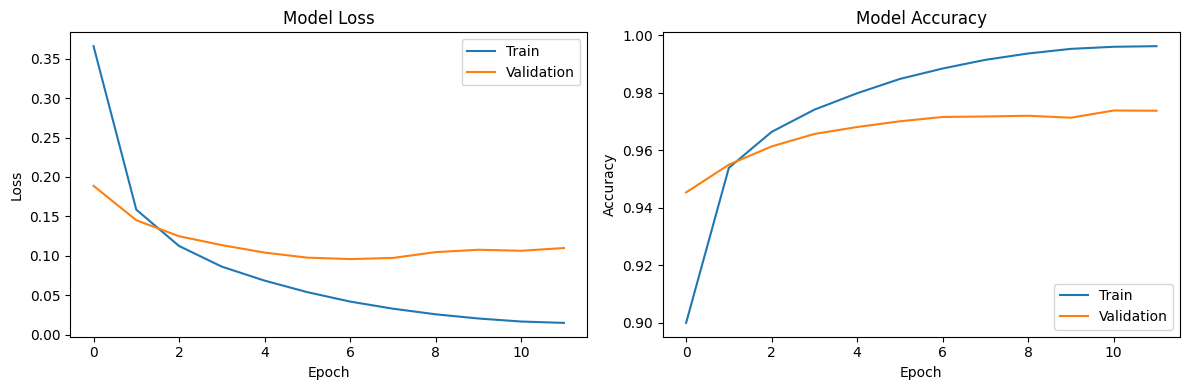

Training stopped at epoch 12


In [33]:
# Plot training & validation loss values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')

plt.tight_layout()
plt.show()

# Print the epoch where training stopped
print(f"Training stopped at epoch {len(history.history['loss'])}")


# Step 7: Launch and Use TensorBoard

In [36]:
%load_ext tensorboard
%tensorboard --logdir=logs/fit


# Step 8: Load the Best Model and Evaluate It

In [39]:
# Load the best model saved by ModelCheckpoint
best_model = tf.keras.models.load_model(checkpoint_filepath)


In [41]:
# Evaluate on test data
test_loss, test_acc = best_model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")


313/313 - 2s - 6ms/step - accuracy: 0.9759 - loss: 0.0852
Test accuracy: 0.9759


# Step 9: Understanding and Addressing Gradient Problems

In [44]:
# Add a callback to monitor gradient norms
class GradientMonitor(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        grads = self.model.optimizer.get_gradients(self.model.total_loss, self.model.trainable_weights)
        norm = tf.sqrt(sum([tf.reduce_sum(tf.square(g)) for g in grads]))
        print(f"Epoch {epoch}: Gradient norm: {norm}")


In [46]:
# Add this to your callbacks list
gradient_monitor = GradientMonitor()
callbacks.append(gradient_monitor)


In [48]:
gradient_monitor

In [ ]:
# Step 8: Load the Best Model and Evaluate it

In [50]:
# Gradient Clipping: Limits the maximum size of gradients
# Apply gradient clipping when compiling the model
from tensorflow.keras.optimizers import Adam

optimizer = Adam(clipnorm=1.0)  # Clip gradients to a maximum norm of 1
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [52]:
# Reduce Learning Rate: Use a smaller learning rate or implement learning rate reduction
# Add ReduceLROnPlateau callback
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,            # Reduce learning rate by 80%
    patience=3,            # Wait 3 epochs of no improvement
    min_lr=0.00001         # Don't go below this learning rate
)
callbacks.append(reduce_lr)
